In [59]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    BatchNormalization,
    Activation,
    Concatenate,
    Dropout,
    Reshape,
    LayerNormalization,
    MultiHeadAttention
)

In [60]:
import os
import cv2
import numpy as np

from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

image_dir = r"F:\work\python\archive\sample segmentation\images"
mask_dir = r"F:\work\python\archive\sample segmentation\masks"

images = []
masks = []

IMG_SIZE = 256

for img_name in os.listdir(image_dir):

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, img_name)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    mask = cv2.imread(mask_path, 0)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks = np.array(masks)

print("Images:", images.shape)
print("Masks:", masks.shape)

Images: (1500, 256, 256, 3)
Masks: (1500, 256, 256)


In [61]:
images = images / 255.0

masks = np.expand_dims(masks, axis=-1)
masks = masks / 255.0

In [62]:
print(images.shape)
print(masks.shape)

(1500, 256, 256, 3)
(1500, 256, 256, 1)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1200, 256, 256, 3)
Test: (300, 256, 256, 3)


In [64]:
def dice_coefficient(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

In [75]:
def iou_metric(y_true, y_pred):

    smooth = 1e-6

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)

In [66]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


def combined_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    return bce + dice_loss(y_true, y_pred)

In [67]:
# CNN encoder

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D

def encoder_block(x, filters):
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    
    p = MaxPooling2D((2,2))(x)
    return x, p

In [68]:
# from tensorflow.keras.layers import Input
# inp = Input(shape=(256, 256, 3))

# # Pass through encoder block
# x, p = encoder_block(inp, filters=64)

# # Build a model to inspect outputs
# model = tf.keras.Model(inputs=inp, outputs=[x, p])
# model.summary()


In [69]:
def decoder_block(x, skip, filters):
    x = UpSampling2D((2,2))(x)
    x = Concatenate()([x, skip])

    x = Conv2D(filters, 3,padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

In [70]:
# swin transformer block
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention
from tensorflow.keras.layers import Reshape

def attention_block(x):

    h = x.shape[1]
    w = x.shape[2]
    c = x.shape[3]

    x_flat = Reshape((h*w, c))(x)

    attn = MultiHeadAttention(
        num_heads=4,
        key_dim=c//4
    )(x_flat, x_flat)

    x_flat = LayerNormalization()(x_flat + attn)

    x = Reshape((h, w, c))(x_flat)

    return x


In [71]:
from tensorflow.keras.layers import Input, BatchNormalization, Activation, Dropout, UpSampling2D
def build_model(input_shape=(256,256,3)):

    inputs = Input(input_shape)

    # Encoder
    x1, p1 = encoder_block(inputs, 64)
    x2, p2 = encoder_block(p1, 128)
    x3, p3 = encoder_block(p2, 256)
    x4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b1 = Conv2D(1024,3,padding="same")(p4)
    b1 = BatchNormalization()(b1)
    b1 = Activation("relu")(b1)

    b1 = Dropout(0.3)(b1)

    b1 = attention_block(b1)

    # Decoder
    d1 = decoder_block(b1, x4, 512)
    d2 = decoder_block(d1, x3, 256)
    d3 = decoder_block(d2, x2, 128)
    d4 = decoder_block(d3, x1, 64)

    outputs = Conv2D(1,1,activation="sigmoid")(d4)

    model = Model(inputs, outputs)

    return model

# model.summary()

In [72]:
model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=["accuracy",dice_coefficient, iou_metric]
)


In [73]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_dice_coefficient',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    mode='max'
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor='val_dice_coefficient',
    save_best_only=True,
    mode='max'
)

In [76]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=16,
    callbacks=[reduce_lr, checkpoint]
)

Epoch 1/10


ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list of length 0 less than minimum 1.

In [ ]:
predictions = model.predict(X_test)

print(predictions.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step
(300, 256, 256, 1)


In [ ]:


pred_mask = (predictions > 0.5).astype(np.uint8)

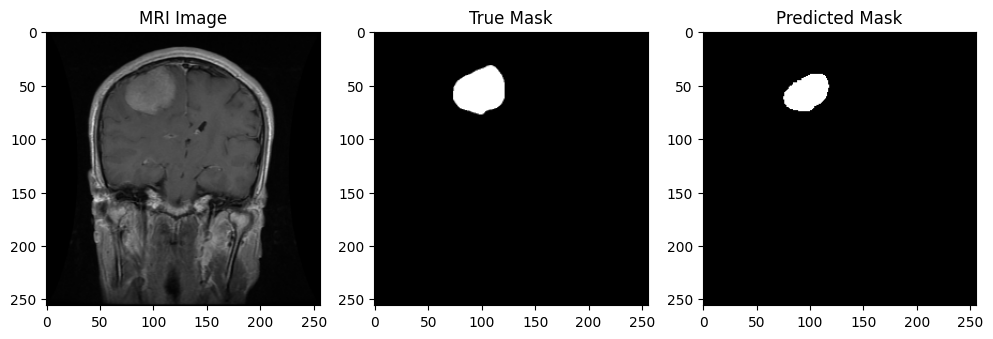

In [ ]:


from matplotlib import pyplot as plt

index = 5

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("MRI Image")
plt.imshow(X_test[index])

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(y_test[index].squeeze(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred_mask[index].squeeze(), cmap="gray")

plt.show()

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    BatchNormalization, Activation, Concatenate,
    Dropout, Reshape, LayerNormalization, MultiHeadAttention
)


image_dir = r"F:\work\python\archive\sample segmentation\images"
mask_dir = r"F:\work\python\archive\sample segmentation\masks"

images = []
masks = []

for file in os.listdir(image_dir):

    img = cv2.imread(os.path.join(image_dir, file))
    img = cv2.resize(img,(256,256))

    mask = cv2.imread(os.path.join(mask_dir, file),0)
    mask = cv2.resize(mask,(256,256))

    images.append(img)
    masks.append(mask)

images = np.array(images)/255.0
masks = np.array(masks)/255.0


print("Images:",images.shape)
print("Masks:",masks.shape)

Images: (1500, 256, 256, 3)
Masks: (1500, 256, 256)


In [2]:
images = images / 255.0

masks = np.expand_dims(masks, axis=-1)
masks = masks / 255.0
print("Images:",images.shape)
print("Masks:",masks.shape)

Images: (1500, 256, 256, 3)
Masks: (1500, 256, 256, 1)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print("X_train:",X_train.shape)
print("y_train:",y_train.shape)

X_train: (1200, 256, 256, 3)
y_train: (1200, 256, 256, 1)


In [4]:
def dice_coefficient(y_true,y_pred):

    smooth = 1e-6

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2.*intersection + smooth)/(
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )




In [5]:
def iou_metric(y_true,y_pred):

    smooth = 1e-6

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection

    return (intersection + smooth)/(union + smooth)




In [6]:
def dice_loss(y_true,y_pred):
    return 1 - dice_coefficient(y_true,y_pred)


def combined_loss(y_true,y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true,y_pred)
    return bce + dice_loss(y_true,y_pred)



In [7]:
def encoder_block(x,filters):

    x = Conv2D(filters,3,padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters,3,padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    p = MaxPooling2D((2,2))(x)

    return x,p


In [8]:

def decoder_block(x,skip,filters):

    x = UpSampling2D((2,2))(x)
    x = Concatenate()([x,skip])

    x = Conv2D(filters,3,padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters,3,padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x



In [9]:
def attention_block(x):

    h = x.shape[1]
    w = x.shape[2]
    c = x.shape[3]

    x_flat = Reshape((h*w,c))(x)

    attn = MultiHeadAttention(
        num_heads=4,
        key_dim=c//4
    )(x_flat,x_flat)

    x_flat = LayerNormalization()(x_flat + attn)

    x = Reshape((h,w,c))(x_flat)

    return x




In [10]:
def build_model(input_shape=(256,256,3)):

    inputs = Input(input_shape)

    x1,p1 = encoder_block(inputs,32)
    x2,p2 = encoder_block(p1,64)
    x3,p3 = encoder_block(p2,128)
    x4,p4 = encoder_block(p3,256)

    # Bottleneck
    b1 = Conv2D(512,3,padding="same")(p4)
    b1 = BatchNormalization()(b1)
    b1 = Activation("relu")(b1)

    b1 = Dropout(0.3)(b1)

    b1 = attention_block(b1)

    # Decoder
    d1 = decoder_block(b1,x4,256)
    d2 = decoder_block(d1,x3,128)
    d3 = decoder_block(d2,x2,64)
    d4 = decoder_block(d3,x1,32)

    outputs = Conv2D(1,1,activation="sigmoid")(d4)

    model = Model(inputs,outputs)

    return model

In [14]:
model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=["accuracy",dice_coefficient,iou_metric]
)

# model.summary()

In [15]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_dice_coefficient',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    mode='max'
)



In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=5,
    batch_size=16,
    callbacks=[reduce_lr]
)

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 482s 6s/step - accuracy: 0.9738 - dice_coefficient: 1.3316e-04 - iou_metric: 6.6583e-05 - loss: 1.2454 - val_accuracy: 0.9850 - val_dice_coefficient: 1.1386e-04 - val_iou_metric: 5.6936e-05 - val_loss: 1.4507 - learning_rate: 1.0000e-04
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 765s 10s/step - accuracy: 0.9838 - dice_coefficient: 1.3995e-04 - iou_metric: 6.9978e-05 - loss: 1.1573 - val_accuracy: 0.9850 - val_dice_coefficient: 1.1626e-04 - val_iou_metric: 5.8135e-05 - val_loss: 1.2928 - learning_rate: 1.0000e-04
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 1085s 14s/step - accuracy: 0.9839 - dice_coefficient: 1.3963e-04 - iou_metric: 6.9819e-05 - loss: 1.1375 - val_accuracy: 0.9850 - val_dice_coefficient: 1.1260e-04 - val_iou_metric: 5.6302e-05 - val_loss: 1.1585 - learning_rate: 1.0000e-04
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 936s 12s/step - accuracy: 0.9840 - dice_coefficient: 1.3963e-04 - iou_metric: 6.9820e-05 - loss: 1.1239 - val_accuracy: 0.9850 - val_dice_

In [18]:
predictions = model.predict(X_test)

print(predictions.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
(300, 256, 256, 1)


In [19]:
pred_mask = (predictions > 0.5).astype(np.uint8)

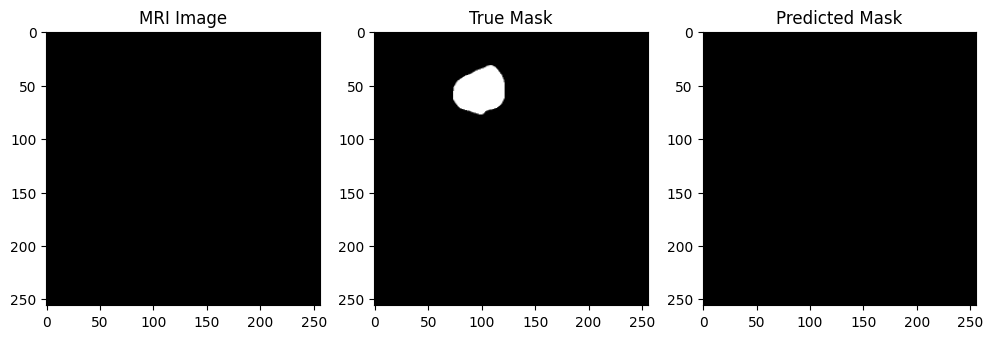

In [20]:
from matplotlib import pyplot as plt

index = 5

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("MRI Image")
plt.imshow(X_test[index])

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(y_test[index].squeeze(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred_mask[index].squeeze(), cmap="gray")

plt.show()